**Analysis of Alveolar Type II Cell Transcriptional States in Lethal COVID-19 Lung Biopsies**

by Ashley Ramsawhook, PhD.

This work is an independent analysis of the Alveolar Type II (AT2) cell transcriptional state in lethal COVID-19 lung biopsies taken from Melms *et al*, 2021 (https://doi.org/10.1038/s41586-021-03569-1). While this notebook reproduces and modifies the pre-processing steps of the raw data performed by the authors, the exploration, analysis, deductions and conclusion are independent and self-directed. The agentic Large Language Model (LLM), Claude Sonnet 5.0 (Anthropic) was utilised for code debugging, statistical methodology discussions and literature dataset navigation. All code and markdown were written by myself.



**The Dataset**

The Melms *et al*, 2021 dataset consisted of lung biopsies extracted from 7 healthy donors and 19 COVID patients harvested post-mortem and sequencing libraries were prepared from single nuclei suspensions. Only one biopsy was harvested per donor, making the terms “Sample” and “Donor” synonymous for this dataset. Ambient RNA and debris contamination had been excluded from raw counts by the authors using CELL BENDER prior to publication of the dataset.   

**External Resources for Annotation**

A curated list of human ribosomal genes was acquired from the Broad Institute's software repository: http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt

**Installing Necessary Libraries and Dependencies**

In [ ]:
%pip install scanpy

In [ ]:
%pip install scvi-tools

In [ ]:
%pip install scikit-misc

In [ ]:
! pip install leidenalg

In [ ]:
! pip install gseapy

In [ ]:
! pip install celltypist --break-system-packages

In [ ]:
! pip install pydeseq2 

**Import the Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import os
import scipy
import glob
from pathlib import Path
import seaborn as sns
from scipy.sparse import csr_matrix, issparse
import scanpy as sc
import scvi
import matplotlib.pyplot as plt
import gseapy as gp
from scipy import stats
import celltypist
from celltypist import models
import requests
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

**Setting the File Paths for Reading-in and Saving Data** 

In [2]:
from pathlib import Path

In [3]:
#Setting the input data path which contains the raw counts files
DATA_DIR = Path("E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/unzipped raw counts")
files = list(DATA_DIR.glob("*.csv"))

In [4]:
#Setting the output path for saving models and processed files
OUTPUT_DIR = "E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/processed"

**Import the Curated Geneset for Ribosomal Gene Annotation**



In [5]:
#Import the Broad Institute's Ribosomal Geneset
RIBO_LIST = Path("E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/KEGG_RIBOSOME.v2026.1.Hs.txt" )
ribo_genes = pd.read_table(RIBO_LIST, skiprows=2, header= None)

**Investigation of AT2 Cell Identity Stability Between Conditions**

Considering that 338 P53 target genes were significantly differentially expressed in multiple cell types with AT2 cells being most represented amongst the top 10 significant hits, AT2 core marker gene expression were examined between COVID-19 and control conditions to assess AT2 identity stability. 

... storing 'cell_type' as categorical
... storing 'condition' as categorical


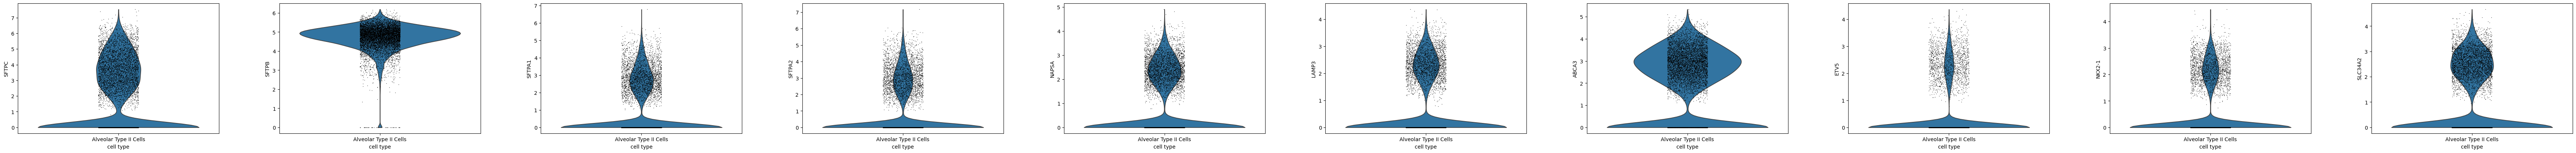

In [181]:
sc.pl.violin(
    adata_combined[adata_combined.obs["cell_type"] == "Alveolar Type II Cells"],
    ["SFTPC", "SFTPB", "SFTPA1", "SFTPA2", "NAPSA", "LAMP3", "ABCA3", "ETV5", "NKX2-1", "SLC34A2"],
    groupby="cell_type"
)

For the core Alveolar Type II cell marker genes, a patten of two discrete populations were observed within the Alveolar Type II cluster. All genes except for SFTPB possessed a greater number of cells exhibiting no expression than the number of expressing cells. 

... storing 'cell_type' as categorical
... storing 'condition' as categorical


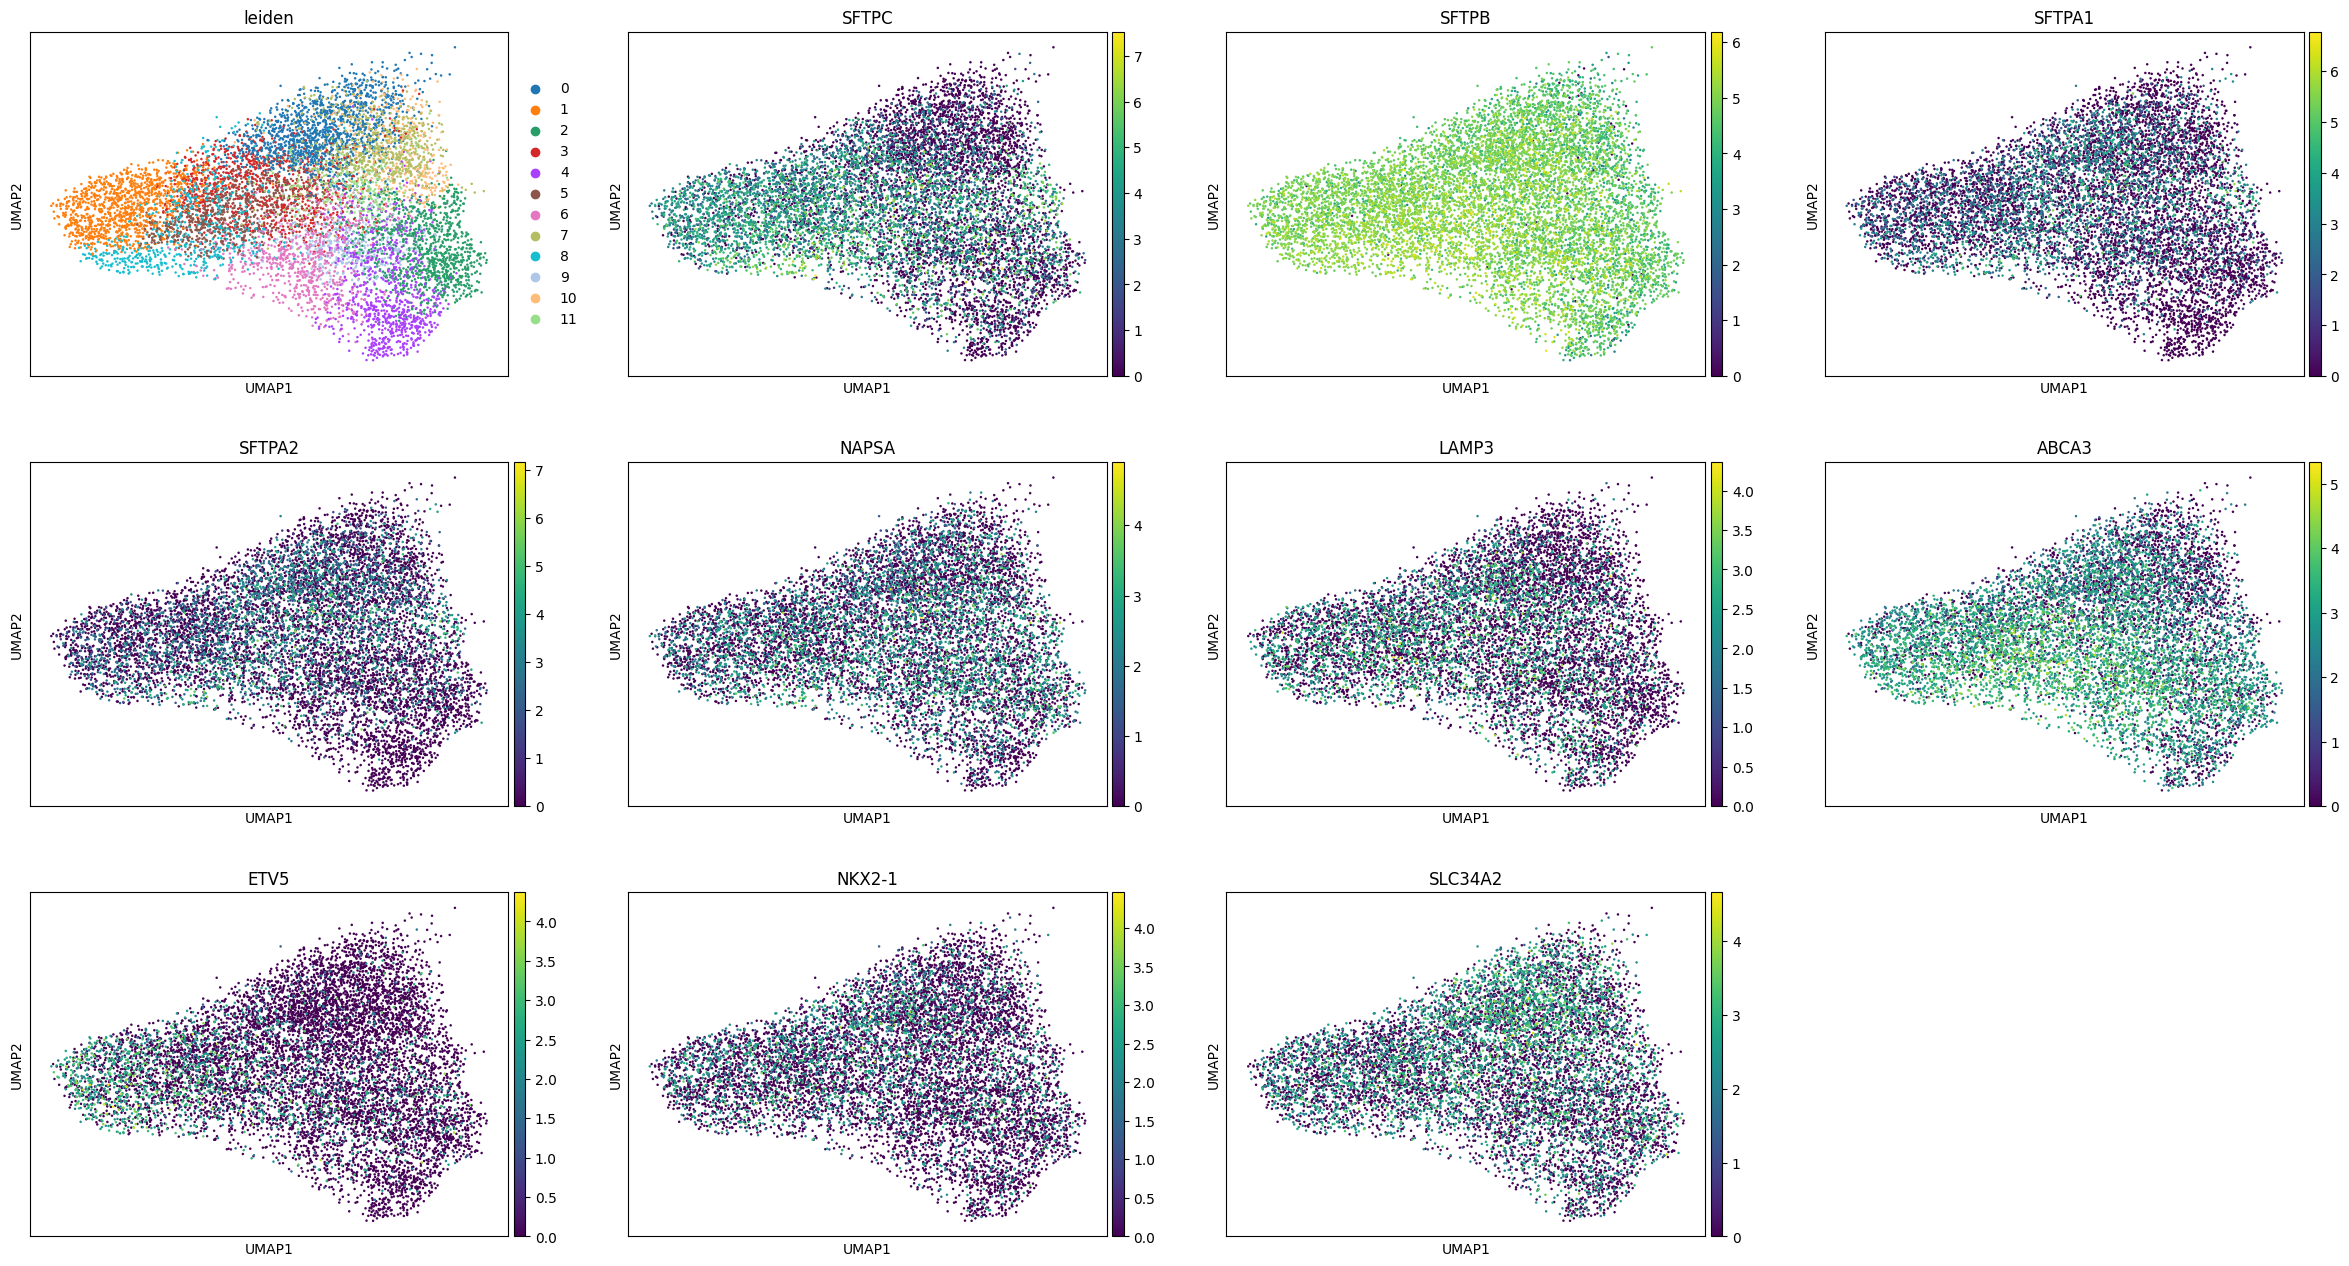

In [ ]:
#Visualising AT2 core marker gene expression
subset_at2_cells = adata_combined[adata_combined.obs["cell_type"] == "Alveolar Type II Cells"].copy()
sc.pp.neighbors(subset_at2_cells, use_rep="X_scVI")
sc.tl.leiden(subset_at2_cells, resolution=1)  
sc.pl.umap(subset_at2_cells, color=["leiden", "SFTPC", "SFTPB", "SFTPA1", "SFTPA2", "NAPSA", "LAMP3", "ABCA3", "ETV5", "NKX2-1", "SLC34A2"])

Interrogation of the AT2 cluster with the Leiden algorithm produced 12 zones of slightly overlapping gene expression from normalised counts. Overlaying AT2 core marker gene expression against the AT2 cell cluster revealed diffuse patterns of varying expression levels across the cluster. Notably, *SFTPC* and *ETV5* exhibited expression concentrated towards the left corner of the roughly trianglualr cluster while *SFTPA1*, *SFTPA2*, *NAPSA*, *LAMP3* and *NKX2-1* displayed concentrated expression towards the centre of the cluster. *ABCA3*'s expression appeared as a diffuse gradient concentrated at the bottom centre and left of the cluster, decreasing in intensity towards the top right corner of the cluster. Higher *SLC34A2* expression appeared more concentrated towards the top right of the cluster whereas *SFTPB* expression was close to uniformly highly expressed (> 4) across the cluster.   

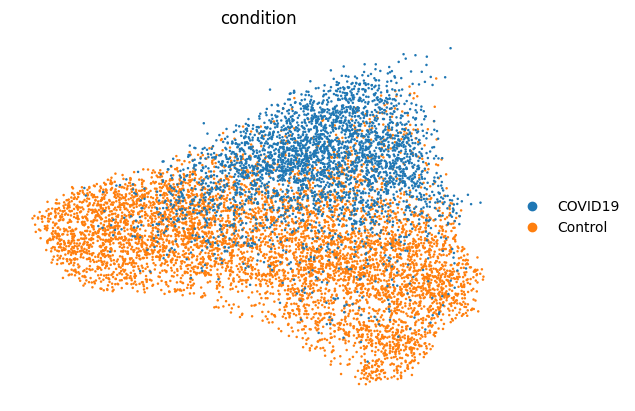

In [ ]:
#Viewing AT2 cell cluster by condition
sc.pl.umap(subset_at2_cells, color= ["condition"], vmax= 5, frameon=False)


Overlaying the AT2 cell cluster by cell condition revealed a gradient of gene expression overlap between conditions, with control helathy cells concentrated at the bottom and left while COVID-19 cells predominantly localised towards the top right of the triangular cluster. A diffuse overlapping of expression between conditions localised these cells centrally within the cluster. 

**Examining AT2 Cell Marker Gene Expression at the Donor Level**

AT2 Marker gene expressiom was interrogated in AT2 pseudobulk results

In [ ]:
at2_identity_markers = [
    "SFTPC", "SFTPB", "SFTPA1", "SFTPA2", "NAPSA", "LAMP3", "ABCA3", "ETV5", "NKX2-1", "SLC34A2"
]

at2_status2 = at2_results_df.loc[at2_results_df.index.isin(at2_identity_markers)]
at2_status2 = at2_status2.sort_values("log2FoldChange")
at2_status2 
at2_status_list = at2_status2.index.tolist()
at2_status_list

All core marker genes are present in the AT2 differentially expressed list. 

In [ ]:
#Run GSEA pre-rank on the AT2 diff exp genes against the AT2 identity genes 
at2_identity_gsea = gp.prerank(
    rnk = at2_ranking,
    gene_sets= {"AT2_identity" : at2_status_list},
    permutation_num= 5000,
    min_size= 5,
    seed=42,
    outdir=None
)

at2_identity_gsea.res2d[
    ["Term", "NES", "NOM p-val", "FDR q-val"]
]

AT2 core genes were downregulated (NES = -1.23) but not signifcantly. 

**Interrogation of ALveolar Type I Marker Expression in AT2 Cells**

Next, Alveolar Type I cell (AT1) expression was examined in AT2 cells. AT2 cells exhibiting significant upregulation of P53 signalling pathway genes might also be undergoing AT1 differentiation.

In [ ]:
#Check AT1 identity genes to ascertain whether AT2 cells are actually transdifferentiating
at1_markers = ["CYP4B1", "FXYD3", "KRT18", "KRT8", "KRT19", "TACSTD2", "LIMCH1", "FOLR1", "C19orf33", "KRT7",
               "SFTA1P", "AQP4", "CLIC3", "CLDN18", "SUSD2", "SLC39A8", "HOPX", "SEMA3B", "VEGFA", "CD55", "GPRC5A",
               "TNNC1", "GGTLC1", "ANKRD29", "CLIC5", "ANKRD1", "AGER", "RTKN2", "SCEL", "MSLN", "CAV1", "CAV2", "BEX3"]

at1_status = at2_results_df.loc[at2_results_df.index.isin(at1_markers)]
at1_status = at1_status.sort_values("log2FoldChange")
at1_status 
at1_status_list = at1_status.index.tolist()
at1_status_list

In [189]:
at1_status

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
CLDN18,19.945755,-0.890978,0.684108,-1.302394,1.927818e-01,0.397629
GPRC5A,147.109572,-0.391360,0.315062,-1.242170,2.141738e-01,0.426405
CD55,126.375526,-0.365802,0.466348,-0.784396,4.328075e-01,0.646967
SFTA1P,23.788360,-0.272169,0.470966,-0.577895,5.633347e-01,0.747360
LIMCH1,472.099401,-0.241627,0.174680,-1.383257,1.665860e-01,0.362869
ANKRD29,17.967436,-0.052354,0.380083,-0.137744,8.904427e-01,0.947756
HOPX,157.765573,0.087711,0.330480,0.265405,7.906973e-01,0.891878
KRT8,21.421609,0.192476,0.413904,0.465027,6.419123e-01,0.803291
BEX3,6.528050,0.359951,0.295564,1.217846,2.232825e-01,0.436271
SLC39A8,191.193753,0.383226,0.279143,1.372866,1.697941e-01,0.367030


In [ ]:
at1_identity_gsea = gp.prerank(
    rnk = at2_ranking,
    gene_sets= {"AT1_identity" : at1_status_list},
    permutation_num= 5000,
    min_size= 5,
    seed=42,
    outdir=None
)

at1_identity_gsea.res2d[
    ["Term", "NES", "NOM p-val", "FDR q-val"]
]

Interestingly, AT1 core identity genes were signifcantly upregulated in AT2 cells (NES= 1.86, FDR q-val= 0.00055)

In [191]:
#Check which genes are contributing to the AT1 marker upregulation
at1_identity_gsea.res2d[
    ["Term", "NES", "NOM p-val", "FDR q-val", "Lead_genes"]
]

,Term,NES,NOM p-val,FDR q-val,Lead_genes
0,AT1_identity,1.860542,0.000555,0.000555,MSLN;SCEL;C19orf33;AGER;FXYD3;KRT19;SUSD2;CAV2...


In [ ]:
at1_identity_gsea.res2d["Lead_genes"][0]

The 22 lead genes were assessed to establish what proportion were contributing to AT1 core identity gene upregulation in AT2 cells.

In [36]:
at1_df = at2_results_df.loc[
    at2_results_df.index.intersection(at1_markers)
].copy()

at1_df["is_leading_edge"] = at1_df.index.isin([
    "MSLN","SCEL","C19orf33","AGER","FXYD3","KRT19","SUSD2","CAV2","SEMA3B","CAV1","ANKRD1",
    "CLIC3","TACSTD2","TNNC1","FOLR1","VEGFA","KRT7","CLIC5","SLC39A8","KRT18","BEX3","CYP4B1'"
])

at1_df[
    ["log2FoldChange", "stat", "pvalue", "padj", "is_leading_edge"]
].sort_values("log2FoldChange", ascending=False)

,log2FoldChange,stat,pvalue,padj,is_leading_edge
ANKRD1,4.758242,2.671588,7.549325e-03,0.045478,True
C19orf33,4.331015,4.745896,2.075854e-06,0.000096,True
AGER,4.116121,4.731737,2.226068e-06,0.000102,True
MSLN,3.732025,4.964950,6.871891e-07,0.000043,True
FXYD3,3.283851,4.731503,2.228636e-06,0.000102,True
SUSD2,2.549142,3.697587,2.176587e-04,0.003459,True
SCEL,2.388603,4.890692,1.004821e-06,0.000057,True
CLIC3,2.333759,2.645170,8.164993e-03,0.048150,True
TNNC1,1.938060,1.626325,1.038806e-01,NaN,True
SEMA3B,1.887518,3.550673,3.842477e-04,0.005258,True


In [195]:
len(at1_df.index)

33

In [37]:
#Filter for signficiance
at1_df_sig = at1_df[(at1_df["log2FoldChange"] > 0.5) & (at1_df["padj"] < 0.05)]
at1_df_sig

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,is_leading_edge
MSLN,5.743886,3.732025,0.751674,4.964950,6.871891e-07,0.000043,True
SCEL,67.902079,2.388603,0.488398,4.890692,1.004821e-06,0.000057,True
C19orf33,3.411822,4.331015,0.912581,4.745896,2.075854e-06,0.000096,True
FXYD3,4.882678,3.283851,0.694040,4.731503,2.228636e-06,0.000102,True
AGER,3.568890,4.116121,0.869897,4.731737,2.226068e-06,0.000102,True
KRT19,37.000930,1.524088,0.408338,3.732421,1.896482e-04,0.003097,True
SUSD2,15.707934,2.549142,0.689407,3.697587,2.176587e-04,0.003459,True
CAV2,17.485249,1.649624,0.457145,3.608535,3.079309e-04,0.004480,True
SEMA3B,11.083229,1.887518,0.531594,3.550673,3.842477e-04,0.005258,True
CAV1,17.216131,1.829032,0.646840,2.827643,4.689205e-03,0.032788,True


A total of 21 lead genes were discovered to be associated with the upregulation of AT1 core genes in AT2 cells. 12 leading edge genes were found to be significantly up-regulated in AT2 cells.  

In [ ]:
#Visualising the AT1 leading edge genes in the  AT2 cell cluster

#Visualising AT1 leading edge core marker gene expression
subset_at2_cells = adata_combined[adata_combined.obs["cell_type"] == "Alveolar Type II Cells"].copy()
sc.pp.neighbors(subset_at2_cells, use_rep="X_scVI")
sc.tl.leiden(subset_at2_cells, resolution=1)  
sc.pl.umap(subset_at2_cells, color=["leiden", "MSLN", "SCEL", "C19orf33", "FXYD3", "AGER", "KRT19",
                                     "SUSD2", "CAV2", "SEMA3B", "CAV1", "ANKRD1", "CLIC3"])

These leading edge genes seem to be expressed in cells localised in the top right corner of the AT2 cell cluster and also centrally, most prominently with SCEL, KRT19, SUSD2, CAV1 and CAV2. 

**Examining single cell level expression of AT1 and AT2 marker genes in AT2 cells.** 

Gene expression of AT1 and AT2 identity genes was compared at the single cell level.

In [38]:
sc.tl.score_genes(
    at2_subset, 
    gene_list= at2_status_list,
    score_name= "AT2_identity_score"

)


sc.tl.score_genes(
    at2_subset,
    gene_list= at1_status_list,
    score_name= "AT1_indentity_score"
)

... storing 'cell_type' as categorical
... storing 'condition' as categorical


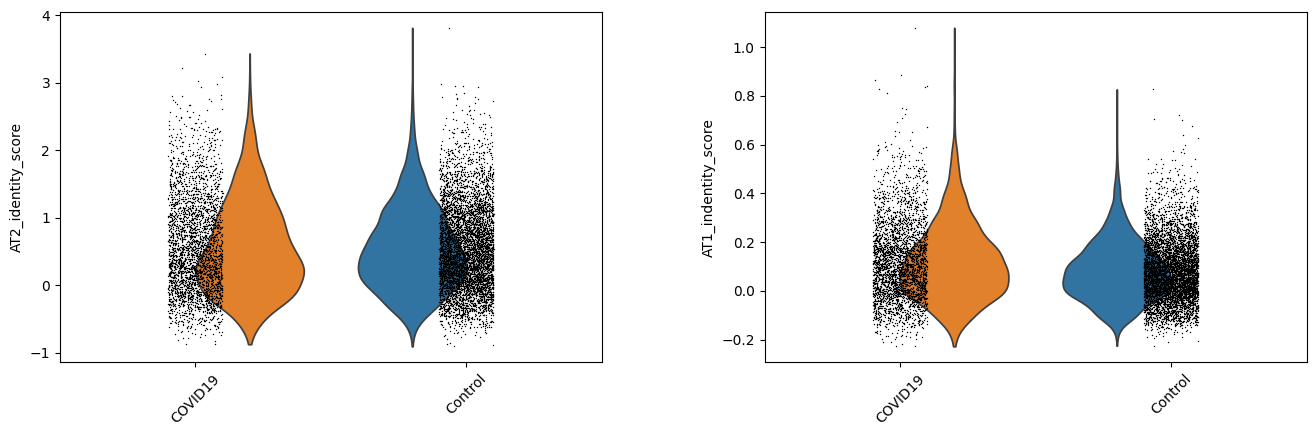

In [199]:
sc.pl.violin(
    at2_subset,
    keys= ["AT2_identity_score", "AT1_indentity_score"],
    groupby= "condition",
    rotation=45
)

The violin plots for the AT2 identity score appear very similar between COVID-19 and control conditions however more cells are present in the control. A greater proportion of cells are closer to 0 AT2 identity in COVID-19 than in controls and exhibit a greater range i AT2 identity score. A greater proportion of cells express a higher AT1 identity score under COVID-19 conditions relative to the control and the range of AT1 identity score expression is higher under COVID-19 conditions.

**Plotting AT1 and AT2 Identity Scores in AT2 Single Cells**

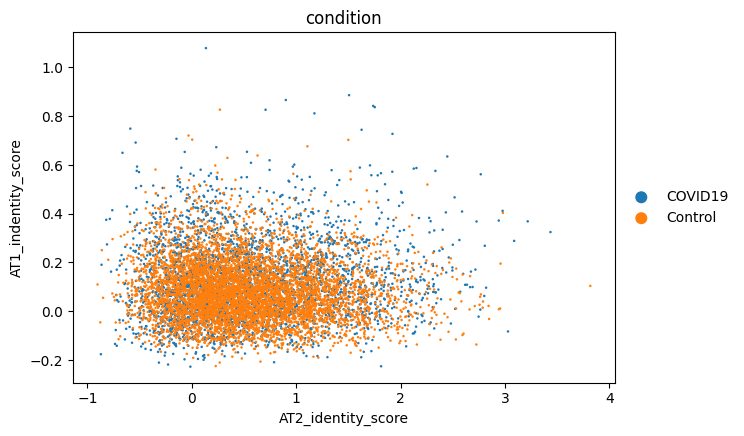

In [200]:
sc.pl.scatter(
    at2_subset,
    x= "AT2_identity_score",
    y= "AT1_indentity_score",
    color= "condition"
)

The AT1 and AT2 identity score distribution in AT2 cells between conditions exhibit noticeable overlap, with the bulk of the cells localised between 0 and 2 on the AT2 identity score scale and 0 and 0.4 on the AT1 identity score scale. The highest AT1 ideneity score cell (> 1) was attributed to the COVID-19 condition with an AT2 identity score slightly above 0 while a control cell possessed the highest AT2 cscore just below 4 with an AT1 score just below 0.2. Multiple COVID-19 and control cells break off from the main cluster bulk, with a greater preponderance of them localised above 2 on the AT2 identity axis and 0.4 on the At1 identity axis than below 0 on either axis.   

To investigate whether the higher AT1 and AT2 identity scoring cells were stressed, dying, doublets or artifacts, AT1 and AT2 identity score were plotted against gene counts and percentage mitochondrial counts.

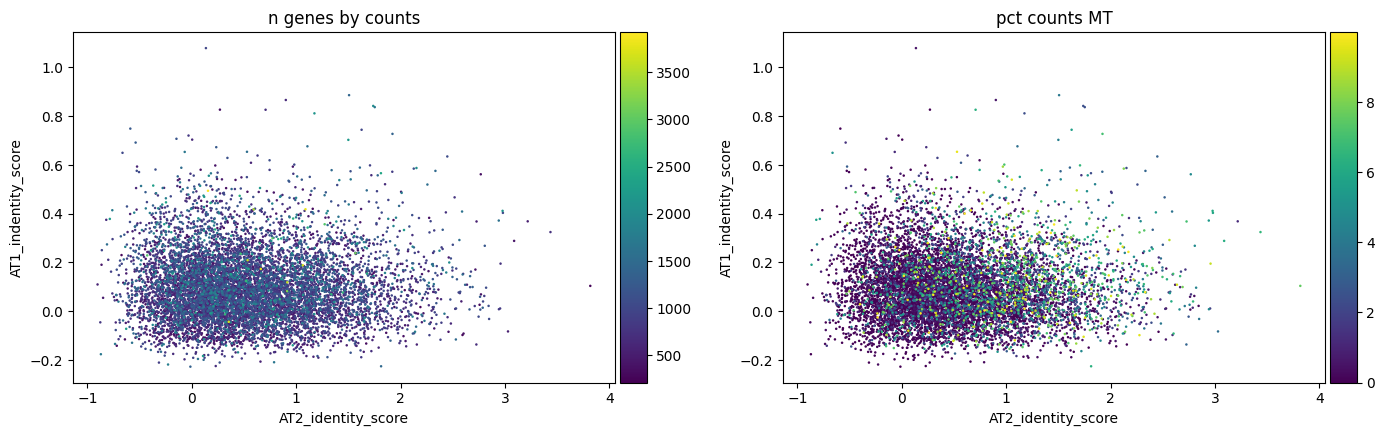

In [201]:
#Plot AT1 and AT2 score against genes_by_count and pct_counts_MT
sc.pl.scatter(
    at2_subset, 
    x= "AT2_identity_score", 
    y= "AT1_indentity_score",
    color= ["n_genes_by_counts", "pct_counts_MT"]
)

The scatterplots illustrate considerable overlap between cells with high and low gene counts within the bulk cluster of cells and with the diffuse break-off  of cells. More cells exhibiting low gene counts (approximately 500) are possess higher AT1 and AT2 identity scores than medium gene counts (2000-2500). Additionally, the main cluster cells predominately possess low (0-2%) mitochondrial counts than the break-off cells (> 4%) however some cells with mitochondrial counts greater than 6% also appear in the main cluster. Therefore it is difficult too confirm if cells are outliers, dying, doublets or artifacts by eye.

Owing to the unequal cell numbers between conditions,  detecting whether cells with different transcriptional states occupy different positions in the cell space was challenging. Therefore cell numbers were equalised before plotting.  

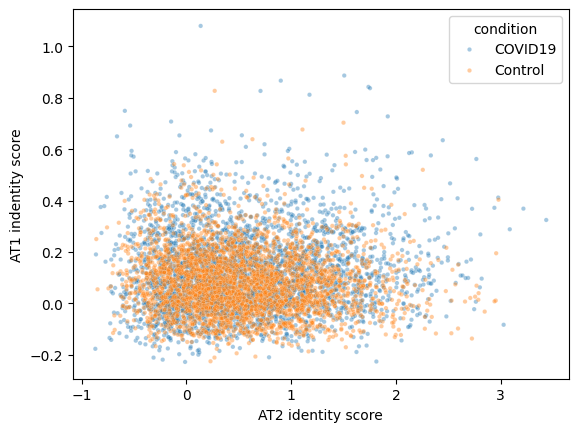

In [205]:
plot_df = at2_subset.obs[
    ["AT2_identity_score", "AT1_indentity_score", "condition"]
].copy()

n_per_condition = plot_df["condition"].value_counts().min()

plot_df_equal = (
    plot_df
    .groupby("condition", group_keys=False)
    .sample(n=n_per_condition, random_state=42)
)

sns.scatterplot(
    data=plot_df_equal,
    x="AT2_identity_score",
    y="AT1_indentity_score",
    hue="condition",
    alpha=0.4,
    s=10
)

plt.xlabel("AT2 identity score")
plt.ylabel("AT1 indentity score")
plt.show()

The control AT2 cells are more tightly packed together relative to the COVID-19 cells which are distributed more diffusely in the main cluster bulk. There is a greater preponderance of COVID-19 cells with higher AT1 identity scores compared to control cells and the highest AT2 identity scoring cells also belong to COVID-19 condition cells.

**Quantitatively Confirming the AT1 and AT2 Identity Score Distribution**

In [39]:
donor_scores = (
    at2_subset.obs.groupby(["Sample", "condition"])[
        ["AT2_identity_score", "AT1_indentity_score"]
    ].mean().reset_index()
)

donor_scores

,Sample,condition,AT2_identity_score,AT1_indentity_score
0,C51ctr,Control,0.528707,0.049030
1,C52ctr,Control,0.432011,0.139176
2,C53ctr,Control,0.814648,0.091449
3,C54ctr,Control,0.815091,0.088770
4,C55ctr,Control,0.098300,0.060775
5,C56ctr,Control,0.129432,0.090048
6,C57ctr,Control,0.850056,0.033393
7,L01cov,COVID19,0.505412,0.132622
8,L03cov,COVID19,0.843843,0.201272
9,L04cov,COVID19,2.075416,0.186709


In [ ]:
donor_scores["AT2_identity_score"].iloc[0:7].mean()

In [ ]:
donor_scores["AT2_identity_score"][7:].mean()

In [ ]:
donor_scores["AT1_indentity_score"].iloc[0:7].mean()

In [ ]:
donor_scores["AT1_indentity_score"].iloc[7:].mean()

While in on average, both control (0.524) and COVID-19 donors (0.714) have similar AT2 identity scores, COVID-19 donors (0.144) have higher AT1 scores than control donors (0.071). Interestingly, two control donors exhibit extremely low AT2 (0.098 and 0.129) and AT1 identity scores (0.060 and 0.090) respectively. There is also a COVID-19 donors with extremely high AT2 identity scores which may be outliers (2.075).

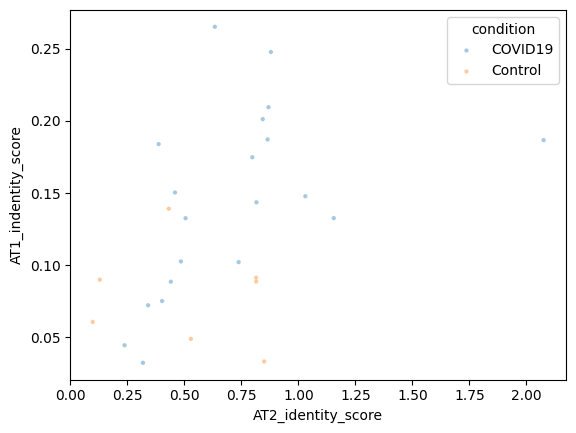

In [219]:
#Plotting the AT1 and AT2 identity scores  by donor
sns.scatterplot(
    data= donor_scores,
    x= "AT2_identity_score",
    y= "AT1_indentity_score",
    hue= "condition",
    alpha= 0.4,
    s=10
)

plt.xlabel("AT2_identity_score")
plt.ylabel("AT1_indentity_score")
plt.show()

There are numerous "High AT1 indentity" donors in the COVID-19 condition compared to the control donors. 

To define "High AT1 identity scores, AT1 identity scores in the COVID-19 condition were classified as "High" if they exceeded the 95th percentile of the control values.  

In [40]:
#Defining the level of "high AT1 identity". 

control_threshold = at2_subset.obs.loc[
    at2_subset.obs["condition"] == "Control",
    "AT1_indentity_score" 
].quantile(0.95)

at2_subset.obs["AT1_high"] = (
    at2_subset.obs["AT1_indentity_score"] > control_threshold
)

The proportion of high AT1 scores from each donor was calculated.

In [41]:
donor_at1 = (
    at2_subset.obs
    .assign(AT1_high=at2_subset.obs["AT1_indentity_score"] > control_threshold)
    .groupby(["Sample", "condition"])
    .agg(
        n_AT2=("AT1_high", "size"),
        n_AT1_high=("AT1_high", "sum")
    )
    .reset_index()
)

donor_at1["fraction_AT1_high"] = (
    donor_at1["n_AT1_high"] / donor_at1["n_AT2"]
)

In [42]:
at1_high_donor = (
    at2_subset.obs.groupby(["Sample", "condition"])["AT1_high"].mean().reset_index()
)

at1_high_donor

,Sample,condition,AT1_high
0,C51ctr,Control,0.022688
1,C52ctr,Control,0.108682
2,C53ctr,Control,0.044888
3,C54ctr,Control,0.054475
4,C55ctr,Control,0.025065
5,C56ctr,Control,0.058333
6,C57ctr,Control,0.006969
7,L01cov,COVID19,0.080645
8,L03cov,COVID19,0.292035
9,L04cov,COVID19,0.142857


In [43]:
#Calculating donor scores by cell number
donor_score_by_cell = (
    at2_subset.obs.groupby(["Sample", "condition"]).agg(
        AT2_score =("AT2_identity_score", "mean"),
        AT1_score =("AT1_indentity_score", "mean"),
        n_AT2=("AT2_identity_score", "size")
    ).reset_index()
)

donor_score_by_cell 

,Sample,condition,AT2_score,AT1_score,n_AT2
0,C51ctr,Control,0.528707,0.049030,573
1,C52ctr,Control,0.432011,0.139176,1555
2,C53ctr,Control,0.814648,0.091449,401
3,C54ctr,Control,0.815091,0.088770,1028
4,C55ctr,Control,0.098300,0.060775,1157
5,C56ctr,Control,0.129432,0.090048,120
6,C57ctr,Control,0.850056,0.033393,1148
7,L01cov,COVID19,0.505412,0.132622,124
8,L03cov,COVID19,0.843843,0.201272,113
9,L04cov,COVID19,2.075416,0.186709,7


In [44]:
donor_score_by_cell["AT1_high"] = at1_high_donor["AT1_high"]
donor_score_by_cell

,Sample,condition,AT2_score,AT1_score,n_AT2,AT1_high
0,C51ctr,Control,0.528707,0.049030,573,0.022688
1,C52ctr,Control,0.432011,0.139176,1555,0.108682
2,C53ctr,Control,0.814648,0.091449,401,0.044888
3,C54ctr,Control,0.815091,0.088770,1028,0.054475
4,C55ctr,Control,0.098300,0.060775,1157,0.025065
5,C56ctr,Control,0.129432,0.090048,120,0.058333
6,C57ctr,Control,0.850056,0.033393,1148,0.006969
7,L01cov,COVID19,0.505412,0.132622,124,0.080645
8,L03cov,COVID19,0.843843,0.201272,113,0.292035
9,L04cov,COVID19,2.075416,0.186709,7,0.142857


In [45]:
#Examining any correlation between donor AT2 cell count and AT1 high score

from scipy.stats import pearsonr

pearson_corr, pearson_p_value = pearsonr(donor_score_by_cell["n_AT2"], donor_score_by_cell["AT1_high"])

print("Pearson Correlation Coefficient:", pearson_corr)
print("Pearson p-value:" , pearson_p_value)

Pearson Correlation Coefficient: -0.4161606520176881
Pearson p-value: 0.0308393404716608


AT1 scores were plotted by donor size and condition.

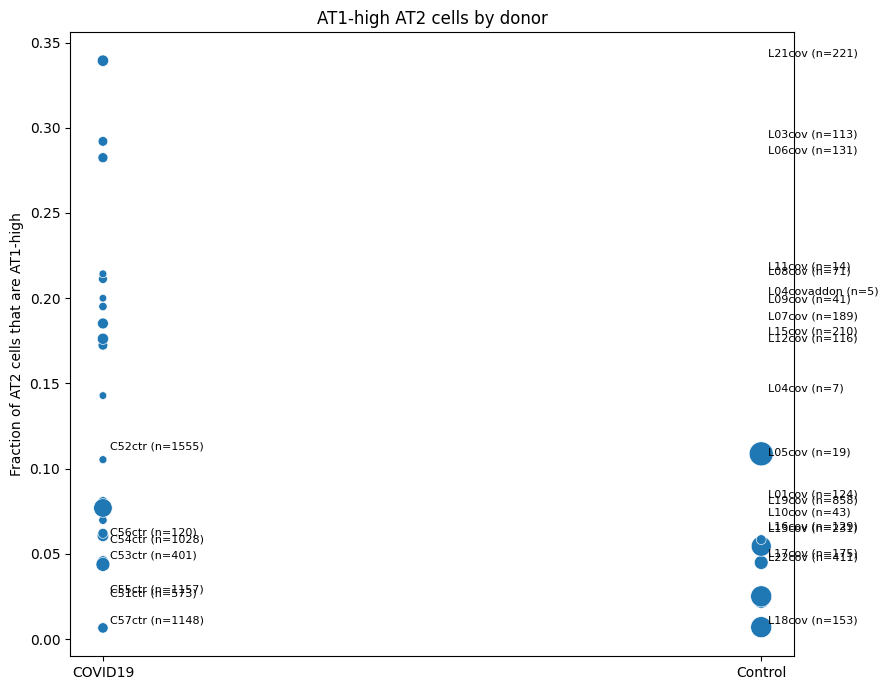

In [227]:
fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=donor_score_by_cell,
    x="condition",
    y="AT1_high",
    size="n_AT2",
    sizes=(30, 300),
    legend=False,
    ax=ax
)

for _, row in donor_score_by_cell.iterrows():

    x = 0 if row["condition"] == "Control" else 1

    ax.annotate(
        f'{row["Sample"]} (n={row["n_AT2"]})',
        xy=(x, row["AT1_high"]),
        xytext=(5, 3),
        textcoords="offset points",
        fontsize=8
    )

ax.set_ylabel("Fraction of AT2 cells that are AT1-high")
ax.set_xlabel("")
ax.set_title("AT1-high AT2 cells by donor")

plt.tight_layout()
plt.show()

The plot clearly illustrates the greater number of high AT1 donors present in the AT2 cells in COVID-19 conditions relative to healthy controls. The high AT1 identity score weakly negatively correlate with donor cell numbers (r= -0.416, p= 0.031) as the highest AT1 identity score donor (0.33) possesses cell numbers (n=221) exceeding those of donors with lower scores (0.0065, n= 153).

To understand if the high AT1 identity scoring cells within the AT2 cell population are a discrete population of independent cells or are transitioning from AT2 cells, Partition-based Graph Abstraction was performed.

... storing 'cell_type' as categorical
... storing 'condition' as categorical


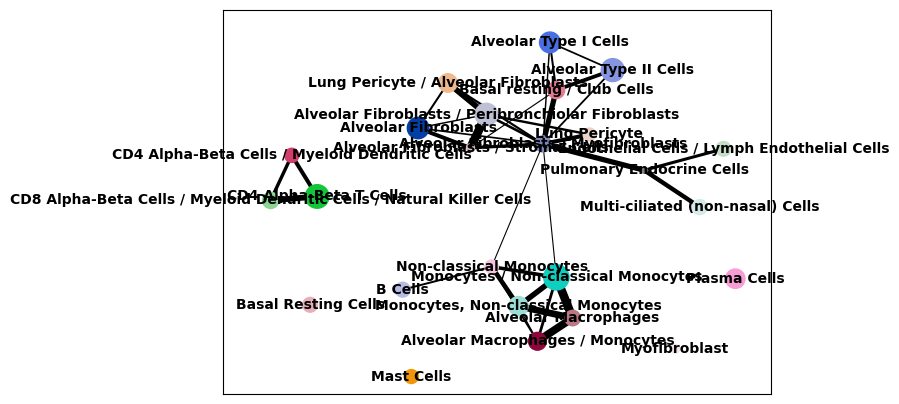

In [228]:
sc.tl.paga(adata_combined, groups="cell_type")
sc.pl.paga(adata_combined, threshold=0.1, color="cell_type")

... storing 'condition' as categorical


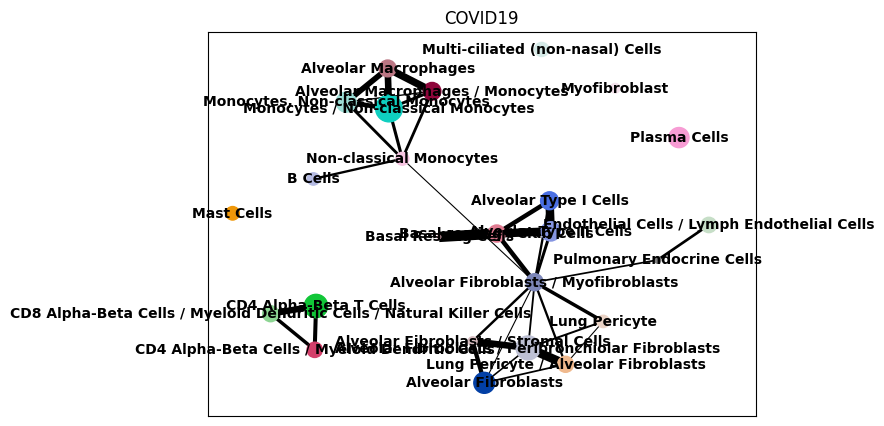

... storing 'condition' as categorical


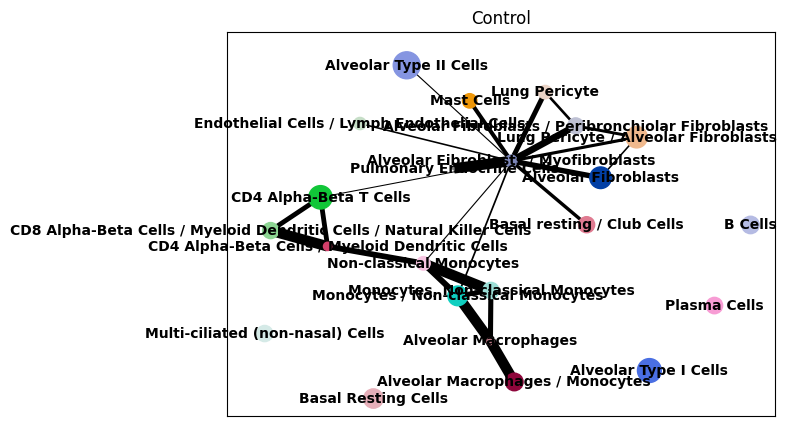

In [47]:
adata_covid = adata_combined[adata_combined.obs["condition"] == "COVID19"]
adata_control = adata_combined[adata_combined.obs["condition"] == "Control"]

sc.tl.paga(adata_covid, groups="cell_type")
sc.pl.paga(adata_covid, threshold=0.1, color="cell_type", title="COVID19")

sc.tl.paga(adata_control, groups="cell_type")
sc.pl.paga(adata_control, threshold=0.1, color="cell_type", title="Control")

In [231]:
print(adata_covid.obs["cell_type"].value_counts())

cell_type
Monocytes / Non-classical Monocytes                                      12003
Alveolar Fibroblasts / Peribronchiolar Fibroblasts                        7767
CD4 Alpha-Beta T Cells                                                    6906
Alveolar Fibroblasts                                                      4564
Plasma Cells                                                              3865
Monocytes, Non-classical Monocytes                                        3759
Alveolar Type II Cells                                                    3261
Alveolar Type I Cells                                                     2411
Alveolar Macrophages / Monocytes                                          2253
Basal resting / Club Cells                                                2016
Alveolar Fibroblasts / Myofibroblasts                                     1984
Alveolar Macrophages                                                      1877
Lung Pericyte / Alveolar Fibroblasts      

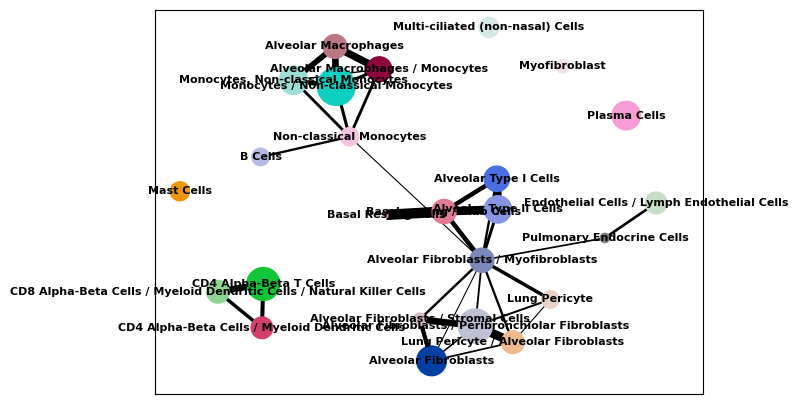

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 236 stored elements and shape (25, 25)>
  Coords	Values
  (0, 1)	0.10585433705398013
  (0, 2)	0.1535180974832212
  (0, 3)	0.41063570678274813
  (0, 5)	0.0015205158964762544
  (0, 6)	0.0032712230973977238
  (0, 8)	0.0019193957699436936
  (0, 11)	0.0007132259199651245
  (0, 12)	0.00036116216830778144
  (0, 13)	0.0009692898488262172
  (0, 14)	0.029301875472796217
  (0, 15)	0.06034072226652556
  (0, 16)	0.16789245956987814
  (0, 17)	0.0025621152512645662
  (0, 18)	7.756443569508726e-05
  (0, 19)	0.0001245038297249603
  (0, 23)	0.00012157300467231804
  (1, 0)	0.10585433705398013
  (1, 2)	0.17683910697990854
  (1, 3)	0.23606265688738676
  (1, 4)	0.0016092327416734685
  (1, 5)	0.07482618426464564
  (1, 6)	0.22460053223984563
  (1, 7)	0.28407379407500893
  (1, 8)	0.05451564999007745
  (1, 10)	0.43443181950630194
  :	:
  (22, 12)	0.01519576611283829
  (22, 14)	0.007952872058576439
  (22, 18)	0.299543709803175
  (22, 19)	0.27265031256

In [232]:
sc.pl.paga(adata_covid, threshold=0.1, color="cell_type", node_size_scale=2, fontsize=8)
# or, more reliably, inspect the numeric connectivity matrix directly:
print(adata_covid.uns["paga"]["connectivities"])

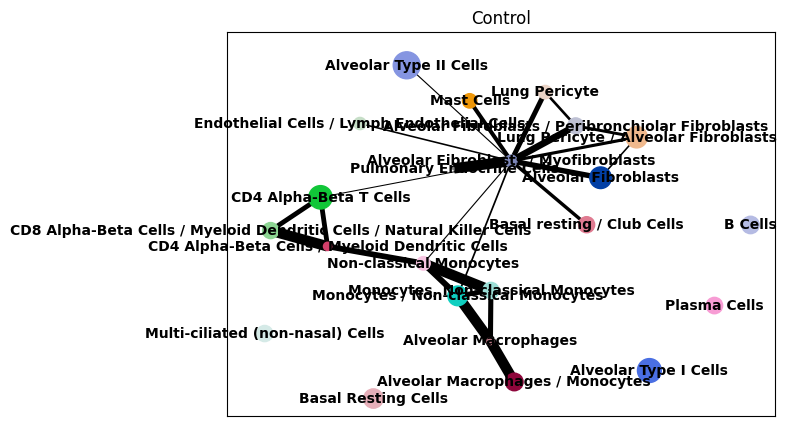

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 172 stored elements and shape (23, 23)>
  Coords	Values
  (0, 1)	0.5186463143302573
  (0, 2)	0.06573713043746715
  (0, 4)	0.0004605383501131011
  (0, 5)	0.0012185874116337383
  (0, 6)	0.00014785234128945516
  (0, 7)	0.0008788659902527306
  (0, 8)	0.00026557139612075245
  (0, 11)	0.0009299239268607885
  (0, 12)	0.0006659430882089629
  (0, 13)	0.0306851468285345
  (0, 14)	0.028030759158133144
  (0, 15)	0.1518996034731537
  (0, 16)	0.005257826335860831
  (0, 17)	0.001249252167467868
  (1, 0)	0.5186463143302573
  (1, 2)	0.6454016525768966
  (1, 4)	0.021032759420679985
  (1, 5)	0.03403358515644871
  (1, 6)	0.10921447649004568
  (1, 7)	0.02598698987534936
  (1, 9)	0.327589922315174
  (1, 11)	0.10060757999795239
  (1, 13)	0.15411366862784281
  (1, 14)	0.47449385419019935
  (1, 15)	0.29962513080336417
  :	:
  (19, 4)	0.01534540178299397
  (19, 5)	0.0008080957965981701
  (19, 6)	0.000489890600668971
  (19, 9)	0.08263183298571411
  (1

In [233]:
sc.tl.paga(adata_control, groups="cell_type")
sc.pl.paga(adata_control, threshold=0.1, color="cell_type", title="Control")
print(adata_control.uns["paga"]["connectivities"])

In [49]:
def paga_to_labeled_df(adata_subset, groupby="cell_type"):
    categories = adata_subset.obs[groupby].cat.categories.tolist()
    conn = adata_subset.uns["paga"]["connectivities"].toarray()
    df = pd.DataFrame(conn, index=categories, columns=categories)
    return df

covid_conn = paga_to_labeled_df(adata_covid)
control_conn = paga_to_labeled_df(adata_control)

print("=== COVID: categories present ===")
print(adata_covid.obs["cell_type"].cat.categories.tolist())
print("\n=== Control: categories present ===")
print(adata_control.obs["cell_type"].cat.categories.tolist())

# Direct AT1-AT2 comparison
print("\nCOVID AT1-AT2 connectivity:", covid_conn.loc["Alveolar Type I Cells", "Alveolar Type II Cells"])
print("Control AT1-AT2 connectivity:", control_conn.loc["Alveolar Type I Cells", "Alveolar Type II Cells"])

# AT1/AT2 vs Alveolar Fibrobalst / Myofibroblasts Cells specifically
print("\nCOVID AT1-Alveolar Fibroblasts / Myofibroblasts:", covid_conn.loc["Alveolar Type I Cells", "Alveolar Fibroblasts / Myofibroblasts"])
print("COVID AT2-Alveolar Fibroblasts / Myofibroblasts:", covid_conn.loc["Alveolar Type II Cells", "Alveolar Fibroblasts / Myofibroblasts"])
print("Control AT1-Alveolar Fibroblasts / Myofibroblasts:", control_conn.loc["Alveolar Type I Cells", "Alveolar Fibroblasts / Myofibroblasts"])
print("Control AT2-Alveolar Fibroblasts / Myofibroblasts:", control_conn.loc["Alveolar Type II Cells", "Alveolar Fibroblasts / Myofibroblasts"])

# AT1/AT2 vs Basal Resting Cells specifically
print("\nCOVID AT1-Basal Resting Cells:", covid_conn.loc["Alveolar Type I Cells", "Alveolar Fibroblasts / Myofibroblasts"])
print("COVID AT2-Basal Resting Cells:", covid_conn.loc["Alveolar Type II Cells", "Basal Resting Cells"])
print("Control AT1-Basal Resting Cells:", control_conn.loc["Alveolar Type I Cells", "Basal Resting Cells"])
print("Control AT2-Basal Resting Cells:", control_conn.loc["Alveolar Type II Cells", "Basal Resting Cells"])

# AT1/AT2 vs Basal Resting / Club Cells specifically
print("\nCOVID AT1-Basal resting / Club Cells:", covid_conn.loc["Alveolar Type I Cells", "Basal resting / Club Cells"])
print("COVID AT2-Basal resting / Club Cells:", covid_conn.loc["Alveolar Type II Cells", "Basal resting / Club Cells"])
print("Control AT1-Basal resting / Club Cells:", control_conn.loc["Alveolar Type I Cells", "Basal resting / Club Cells"])
print("Control AT2-Basal resting / Club Cells:", control_conn.loc["Alveolar Type II Cells", "Basal resting / Club Cells"])



=== COVID: categories present ===
['Alveolar Fibroblasts', 'Alveolar Fibroblasts / Myofibroblasts', 'Alveolar Fibroblasts / Peribronchiolar Fibroblasts', 'Alveolar Fibroblasts / Stromal Cells', 'Alveolar Macrophages', 'Alveolar Macrophages / Monocytes', 'Alveolar Type I Cells', 'Alveolar Type II Cells', 'B Cells', 'Basal Resting Cells', 'Basal resting / Club Cells', 'CD4 Alpha-Beta Cells / Myeloid Dendritic Cells', 'CD4 Alpha-Beta T Cells', 'CD8 Alpha-Beta Cells / Myeloid Dendritic Cells / Natural Killer Cells', 'Endothelial Cells / Lymph Endothelial Cells', 'Lung Pericyte', 'Lung Pericyte / Alveolar Fibroblasts', 'Mast Cells', 'Monocytes / Non-classical Monocytes', 'Monocytes, Non-classical Monocytes', 'Multi-ciliated (non-nasal) Cells', 'Myofibroblast', 'Non-classical Monocytes', 'Plasma Cells', 'Pulmonary Endocrine Cells']

=== Control: categories present ===
['Alveolar Fibroblasts', 'Alveolar Fibroblasts / Myofibroblasts', 'Alveolar Fibroblasts / Peribronchiolar Fibroblasts', 'Alve

The PAGA results demonstrate dramatic changes in connectivities across multiple cell types between conditions. Connectivities between AT1 and AT2 cells increased 130-fold under COVID-19 conditions compared to healthy controls from 0.0062 to 0.814. Large-scale increases in connectivity were consistently observed from control to COVID-19 conditions for AT1 - alveolar fibroblast / myofibroblasts (6.58-fold change), AT2 - alevolar fibroblasts / myofibroblasts (2.61 fold change), AT1 - basal resting / club cells (no connectivity to 0.224), AT1- basal resting cells (23.76 -fold increase) and AT2 - basal resting / club cells (10.69). No change in connectivity was observed between AT2 and basal resting cells between healthy and COVID-19 coniditons. 